
image 1/1 E:\test.jpg: 384x640 8 cars, 1 truck, 164.9ms
Speed: 12.1ms preprocess, 164.9ms inference, 35.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\KRISHNENDU\PyNotebookTutorials\Image analysis DL\runs\detect\predict17
--- Analysis Complete ---

Detected Objects:
 - car (Confidence: 0.88) at coordinates: [892, 765, 1238, 1050]
 - car (Confidence: 0.85) at coordinates: [741, 511, 1031, 741]
 - car (Confidence: 0.81) at coordinates: [1367, 598, 1708, 866]
 - car (Confidence: 0.78) at coordinates: [660, 412, 886, 623]
 - car (Confidence: 0.72) at coordinates: [550, 316, 757, 505]
 - car (Confidence: 0.61) at coordinates: [1008, 335, 1251, 535]
 - car (Confidence: 0.58) at coordinates: [316, 275, 446, 361]
 - car (Confidence: 0.55) at coordinates: [450, 304, 555, 363]
 - truck (Confidence: 0.41) at coordinates: [130, 203, 263, 373]
Checking saved image path: C:\Users\KRISHNENDU\PyNotebookTutorials\Image analysis DL\runs\detect\predict17\test.jpg


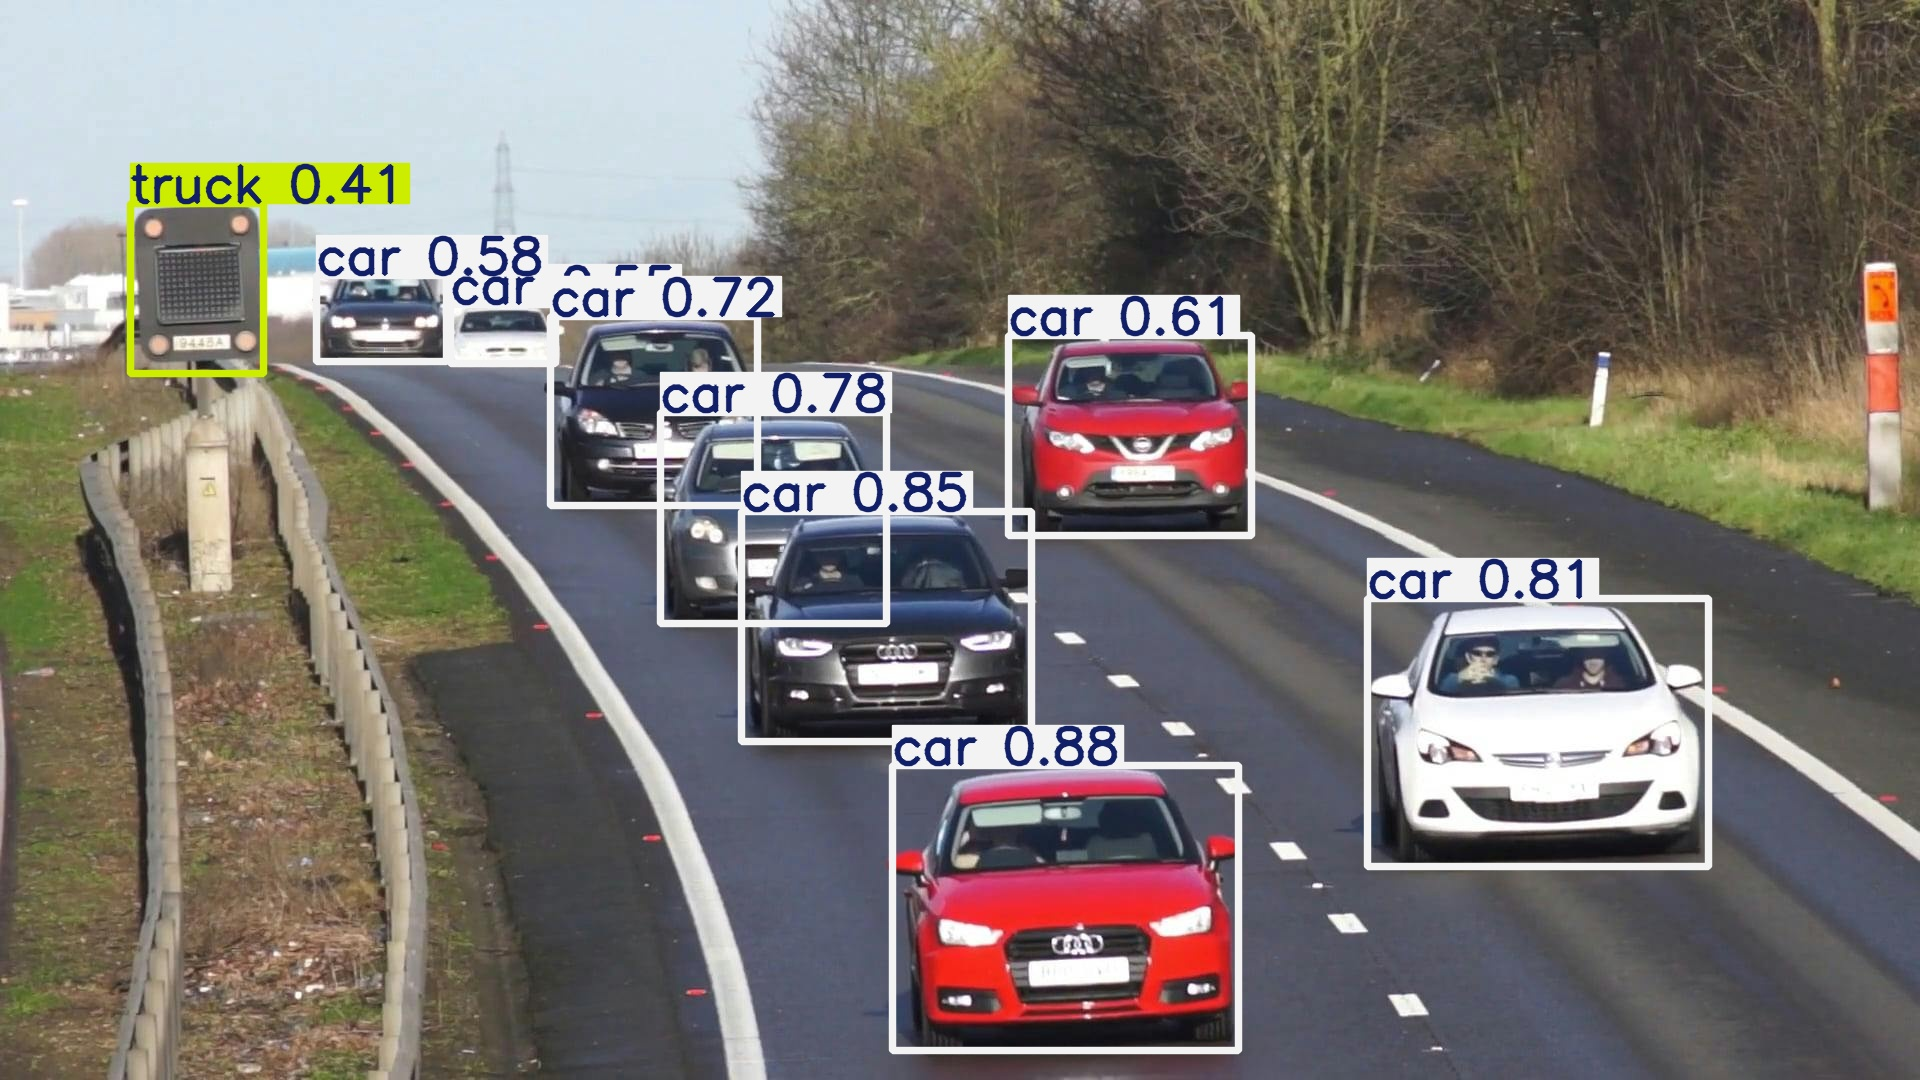

In [1]:
import os
from ultralytics import YOLO
import cv2
from PIL import Image
from IPython.display import display

model = YOLO('yolov8n.pt')
image_path = r"E:\test.jpg"
results = model.predict(source=image_path, conf=0.25, iou=0.7, save=True)
print("--- Analysis Complete ---")

for r in results:
    names = r.names
    print("\nDetected Objects:")
    for box in r.boxes:
        coords = box.xyxy[0].tolist()
        class_id = box.cls[0].item()
        conf = box.conf[0].item()
        class_name = names[int(class_id)]
        print(f" - {class_name} (Confidence: {conf:.2f}) at coordinates: [{int(coords[0])}, {int(coords[1])}, {int(coords[2])}, {int(coords[3])}]")

# Build the saved image path correctly using basename
saved_image_path = os.path.join(results[0].save_dir, os.path.basename(image_path))
print("Checking saved image path:", saved_image_path)

try:
    img_cv2 = cv2.imread(saved_image_path)
    img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(img_rgb))
except Exception as e:
    print(f"Could not load and display the saved image: {e}")
    print(f"Check the output directory: {results[0].save_dir}")
